<a href="https://colab.research.google.com/github/aleksiua/Blog_frontend/blob/main/M%C3%A4rkmiku_thesis_T5gemma_ipynb_koopia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.linalg import expm

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.modeling_outputs import BaseModelOutput

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [ ]:
problems = [
    {
        "id": "angbisec_bline_cyclic",
        "text": """Let A, B, C be the vertices of a triangle. Let F be a point lying on the angle bisector of BAC and on the perpendicular bisector of side BC.
Prove that the points A, B, C, F lie on a common circle using angles."""
    },
    {
        "id": "9point_part1",
        "text": """Let ABC be a triangle. Let D be the foot of the perpendicular from A to side BC. Let E, F, G be the midpoints of sides BA, CB, AC (respectively).
Prove that the points D, E, F, G lie on a common circle using homothety."""
    },
    {
        "id": "9point_part2",
        "text": """Let ABC be a triangle with an orthocenter O. Let E, F, G be the midpoints of BA, CB, AC (respectively). Let H be the midpoint of segment AO.
Prove that the points E, F, G, H lie on a common circle using homothety."""
    },
    {
        "id": "napoleon_ddar_ok",
        "text": """Let A1A2A3 be a triangle. Let B3 be a point on a circle with radius A1A2 and angle A1A2B3 being 60°. Let B1 be a point on a circle with radius A2A3 and angle A2A3B1 being 60°. Let B2 be a point on a circle with radius A3A1 and angle A3A1B2 being 60°. Let c1, c2 and c3 be the circumcenters of B1A2A3, B2A3A1 and B3A1A2, respectively.
Using trigonometry, prove that c1c2=c1c3."""
    },
    {
        "id": "napoleon2",
        "text": """Let A1A2A3 be a triangle. Let c3 be a point so that angles A1A2C3 and A2A1C3 are 30° and 150°, respectively. Let c1 be a point so that angles A2A3C1 and A3A2C1 are 30° and 150°, respectively. Let c2 be a point so that angles A3A1C2 and A1A3C2 are 30° and 150°, respectively.
Using trigonometry, prove that c1c2=c1c3."""
    },
    {
        "id": "ceva",
        "text": """Let ABC be a triangle. Let D be an arbitrary point. Let E,F,G be the intersection points of AD, BD, CD (respectively) with the opposites
BC, CA, AB (respectively).
Using trigonometry, prove that FH/FA and GB/GA are equal ratios."""
    },
    {
        "id": "ceva_hint_ddar_ok",
        "text": """Let ABC be a triangle and D an arbitrary point. Let E be the intersection of BC and AD, F be the intersection of CA and BD and G be the
intersection of AB and CD. Let H lay on CA and HB be parallel to EF. Let I lay on BD and IA be parallel to BC. Let J be the
intersection of AI and CD.
Using trigonometry, prove that FH/FA and GB/GA are equal ratios."""
    },
    {
        "id": "ceva_menelaus_hint_ddar_ok",
        "text": """Let ABC be a triangle and D an arbitrary point. Let E be the intersection of BC and AD, F be the intersection of CA and BD and G be the
intersection of AB and CD. Let H lay on CA and HB be parallel to EF. Let I lay on CD and IE be parallel to AB. Let J lay on
BF and JE be parallel to AC.
Using trigonometry, prove that FH/FA and GB/GA are equal ratios."""
    },
    {
        "id": "square_angle15",
        "text": """Let ABCD be a square. Let E be a point, with angle CDE being 15° and angle DCE being -15°.
Using the laws of right triangles and the pythagorean theorem, prove that EA=AB."""
    }
]

In [ ]:
from huggingface_hub import login, whoami
login()
print(whoami())

In [ ]:
# Smallest practical Gemma-family encoder-decoder choice
model_name = "google/t5gemma-s-s-ul2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
base_model.eval()

In [ ]:
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

def normalize_torch(x, eps=1e-12):
    return x / (x.norm(dim=-1, keepdim=True) + eps)

def normalize_np(x, eps=1e-12):
    return x / (np.linalg.norm(x) + eps)

def sample_lie_algebra_matrix(d, scale=0.03, skew=False, seed=None):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((d, d)) * scale
    if skew:
        A = A - A.T
    return A

def apply_lie_transform(x_np, scale=0.03, skew=False, seed=None):
    d = x_np.shape[0]
    A = sample_lie_algebra_matrix(d=d, scale=scale, skew=skew, seed=seed)
    T = expm(A)
    x_new = T @ x_np
    x_new = normalize_np(x_new)
    return x_new, A, T

encoder: statement → transformer → embedding

In [ ]:
texts = [p["text"] for p in problems]

enc = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    encoder_outputs = base_model.get_encoder()(
        input_ids=enc["input_ids"],
        attention_mask=enc["attention_mask"]
    )
    encoder_hidden = encoder_outputs.last_hidden_state
    embeddings = mean_pool(encoder_hidden, enc["attention_mask"])
    embeddings = normalize_torch(embeddings)

print("encoder hidden:", encoder_hidden.shape)
print("embeddings:", embeddings.shape)

build exact inverse decoder module

In [ ]:
class EmbeddingInverseDecoder(nn.Module):
    def __init__(self, seq2seq_model, emb_dim, prefix_len=16):
        super().__init__()
        self.seq2seq = seq2seq_model
        self.emb_dim = emb_dim
        self.d_model = seq2seq_model.get_encoder().config.hidden_size
        self.prefix_len = prefix_len

        self.embedding_to_prefix = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 2),
            nn.GELU(),
            nn.Linear(emb_dim * 2, prefix_len * self.d_model)
        )

    def make_encoder_outputs(self, z):
        batch_size = z.size(0)
        prefix = self.embedding_to_prefix(z)
        prefix = prefix.view(batch_size, self.prefix_len, self.d_model)
        return BaseModelOutput(last_hidden_state=prefix)

    def forward(self, z, labels=None):
        enc_out = self.make_encoder_outputs(z)
        attention_mask = torch.ones(
            z.size(0),
            self.prefix_len,
            dtype=torch.long,
            device=z.device
        )
        out = self.seq2seq(
            encoder_outputs=enc_out,
            attention_mask=attention_mask,
            labels=labels
        )
        return out

    @torch.no_grad()
    def generate(self, z, **gen_kwargs):
        enc_out = self.make_encoder_outputs(z)
        attention_mask = torch.ones(
            z.size(0),
            self.prefix_len,
            dtype=torch.long,
            device=z.device
        )
        return self.seq2seq.generate(
            encoder_outputs=enc_out,
            attention_mask=attention_mask,
            **gen_kwargs
        )

dataset for exact inverse training

In [ ]:
class InverseDataset(Dataset):
    def __init__(self, texts, tokenizer, z_vectors, max_target_len=256):
        self.texts = texts
        self.tokenizer = tokenizer
        self.z_vectors = z_vectors
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        target = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_target_len,
            return_tensors="pt"
        )
        labels = target["input_ids"].squeeze(0)
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "z": self.z_vectors[idx],
            "labels": labels
        }

def collate_fn(batch):
    z = torch.stack([item["z"] for item in batch], dim=0)
    labels = torch.stack([item["labels"] for item in batch], dim=0)
    return {"z": z, "labels": labels}

create inverse decoder

In [ ]:
z_vectors = embeddings.detach().cpu()

inverse_model = EmbeddingInverseDecoder(
    seq2seq_model=base_model,
    emb_dim=z_vectors.shape[1],
    prefix_len=16
).to(device).float()

freeze base seq2seq, train only inverse mapping

In [ ]:
for param in inverse_model.seq2seq.parameters():
    param.requires_grad = False

train_dataset = InverseDataset(
    texts=texts,
    tokenizer=tokenizer,
    z_vectors=z_vectors
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

optimizer = torch.optim.AdamW(
    inverse_model.embedding_to_prefix.parameters(),
    lr=1e-3
)

train inverse decoder on original embeddings

In [ ]:
inverse_model.train()

epochs = 20

for epoch in range(epochs):
    total_loss = 0.0

    for batch in train_loader:
        z = batch["z"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        out = inverse_model(z, labels=labels)
        loss = out.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1}/{epochs} loss={total_loss/len(train_loader):.4f}")

test exact inverse decoder on original embeddings

In [ ]:
inverse_model.eval()

with torch.no_grad():
    sample_z = z_vectors[:3].to(device)
    gen_ids = inverse_model.generate(
        sample_z,
        max_new_tokens=128,
        num_beams=4
    )

decoded = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

for i, txt in enumerate(decoded):
    print("=" * 80)
    print("ORIGINAL:")
    print(texts[i])
    print()
    print("RECONSTRUCTED:")
    print(txt)
    print()

random projection (Lie algebra), multiple directions, multiple copies

In [ ]:
def make_multiple_copies(z_torch, n_copies=8, scale=0.03, skew=False):
    z_np = z_torch.detach().cpu().numpy()
    copies = []
    matrices_A = []
    matrices_T = []

    for i in range(n_copies):
        z_new, A, T = apply_lie_transform(
            z_np,
            scale=scale,
            skew=skew,
            seed=i
        )
        copies.append(torch.tensor(z_new, dtype=torch.float32))
        matrices_A.append(A)
        matrices_T.append(T)

    return torch.stack(copies, dim=0), matrices_A, matrices_T

exact workflow on one statement

In [ ]:
statement_index = 0

original_statement = texts[statement_index]
original_embedding = z_vectors[statement_index]

copies, As, Ts = make_multiple_copies(
    original_embedding,
    n_copies=8,
    scale=0.03,
    skew=False
)

copies = copies.to(device)

gen_ids = inverse_model.generate(
    copies,
    max_new_tokens=128,
    do_sample=True,
    temperature=0.9,
    top_p=0.95
)

decoded_copies = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

print("=" * 100)
print("ORIGINAL STATEMENT")
print(original_statement)
print()

for i, txt in enumerate(decoded_copies):
    print("=" * 100)
    print(f"COPY {i+1}")
    print(txt)
    print()

run on all statements

In [ ]:
all_results = []

for statement_index, statement_text in enumerate(texts):
    original_embedding = z_vectors[statement_index]

    copies, As, Ts = make_multiple_copies(
        original_embedding,
        n_copies=5,
        scale=0.03,
        skew=False
    )

    copies = copies.to(device)

    gen_ids = inverse_model.generate(
        copies,
        max_new_tokens=128,
        do_sample=True,
        temperature=0.9,
        top_p=0.95
    )

    decoded_copies = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

    row = {
        "id": problems[statement_index]["id"],
        "original": statement_text,
        "copies": decoded_copies
    }
    all_results.append(row)

print("done")

inspect results

In [ ]:
for row in all_results:
    print("#" * 120)
    print("ID:", row["id"])
    print()
    print("ORIGINAL:")
    print(row["original"])
    print()
    for i, c in enumerate(row["copies"]):
        print(f"COPY {i+1}:")
        print(c)
        print()

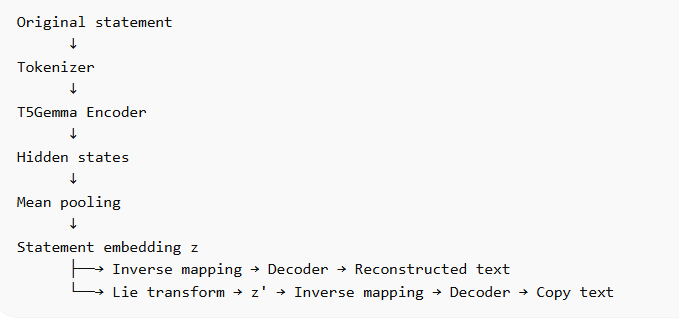